<a href="https://colab.research.google.com/github/umraodeepika7-dotcom/ctgan/blob/main/Copy_of_biohydrogenRSSDV_Synthesize_a_table_(CTGAN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[SDV Docs](https://docs.sdv.dev/sdv) > [Tutorials](https://docs.sdv.dev/sdv/tutorials)

# Synthesize a Table (CTGAN)

In this notebook, we'll use the SDV to create synthetic data for a single table and evaluate it. The SDV uses machine learning to learn patterns from real data and emulates them when creating synthetic data.

We'll use the **CTGAN** algorithm to do this. CTGAN uses generative adversarial networks (GANs) to create synthesize data with high fidelity.

_Last Edit: January 30, 2026_

# 0. Installation

Install SDV Community.

In [ ]:
%pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.9/206.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 8.1 MB/s eta 0:00:00


In [ ]:
!pip install table_evaluator

In [ ]:
!pip install dython

 Loading the experimental data for biohydrogen production from rice straw hydrolyste (Chang, Alex CC, et al.2011).

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Biohydrogen_production.csv to Biohydrogen_production.csv


In [ ]:
import pandas as pd
data = pd.read_csv('Biohydrogen_production.csv')

In [ ]:
real_data = pd.read_csv('Biohydrogen_production.csv')

In [ ]:
display(real_data.head(35))

,Catalyst,RS conc. (g/L),Nutrient,Sugar consumed (%),HAc (mg/L),HPr (mg/L),n-Hbu (mg/L),i-Hbu (mg/L),TVFA (mg/L),HY mmol/g rice straw,P (ml),Rm (ml/h),tm (h),λ (h),R-square
0,Water,3,No,81,1183,898,1520,553,4155,0.0026,42.62,4.11,11.45,7.64,0.9859
1,Water,3,Yes,50,1593,1445,1594,754,5388,0.0016,27.05,2.21,10.60,6.1,0.9973
2,H2SO4,3,No,36,519,114,222,89,991,0.1911,22.54,0.36,14.14,−8.89,0.9735
3,H2SO4,10,No,29,876,118,666,3940,1897,0.1048,39.44,0.84,21.77,4.5,0.9898
4,H2SO4,20,No,23,720,90,284,188,1283,0.0335,26.76,0.71,9.58,−4.29,0.9735
5,H2SO4,25,No,96,1184,100,377,51,1714,0.0244,23.29,1.22,8.00,0.98,0.9742
6,H2SO4,3,Yes,94,683,114,121,58,1009,0.1054,12.92,0.43,14.86,3.81,0.9913
7,H2SO4,10,Yes,77,1201,494,1359,1202,4257,0.1237,49.72,1.44,18.03,5.33,0.9946
8,H2SO4,20,Yes,86,1311,855,4923,2057,9147,0.1313,104.03,2.24,23.26,6.17,0.9984
9,H2SO4,25,Yes,83,1681,3005,8014,7168,"42,287",0.1429,144.22,3.16,25.67,8.88,0.9989


This includes **metadata**, a description of the dataset. It includes the primary keys as well as the data types for each column (called "sdtypes").

In [ ]:
categorical_features = ['Catalyst', 'Nutrient']

Table name configured: Biohydrogen_production_table
Updated Metadata:
{'Catalyst': {'sdtype': 'categorical'}, 'RS conc. (g/L)': {'sdtype': 'numerical'}, 'Nutrient': {'sdtype': 'categorical'}, 'Sugar consumed (%)': {'sdtype': 'numerical'}, 'HAc (mg/L)': {'sdtype': 'numerical'}, 'HPr (mg/L)': {'sdtype': 'numerical'}, 'n-Hbu (mg/L)': {'sdtype': 'numerical'}, 'i-Hbu (mg/L)': {'sdtype': 'numerical'}, 'TVFA (mg/L)': {'sdtype': 'numerical'}, 'HY mmol/g rice straw': {'sdtype': 'numerical'}, 'P\xa0(ml)': {'sdtype': 'numerical'}, 'Rm\xa0(ml/h)': {'sdtype': 'numerical'}, 'tm\xa0(h)': {'sdtype': 'numerical'}, 'λ\xa0(h)': {'sdtype': 'numerical'}, 'R-square': {'sdtype': 'numerical'}}
Primary key for table: None
Metadata visualization:


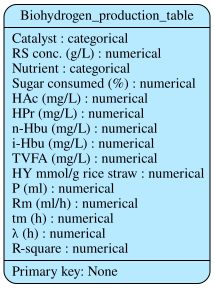

In [ ]:
from sdv.metadata import Metadata
from IPython.display import display

user_desired_table_name = 'Biohydrogen_production_table'

# Initialize metadata by detecting from the dataframe with the desired table name.
# This method will automatically infer column types and other metadata details.
metadata = Metadata.detect_from_dataframe(data=real_data, table_name=user_desired_table_name)

# Now, update column sdtypes based on categorical_features list by directly modifying the columns dictionary
for col in real_data.columns:
    if col in categorical_features:
        metadata.tables[user_desired_table_name].columns[col]['sdtype'] = 'categorical'
    else:
        # For numerical columns, ensure they are set to numerical.
        # Explicitly setting is safer as default detection might categorize some numbers as discrete.
        metadata.tables[user_desired_table_name].columns[col]['sdtype'] = 'numerical'

# Explicitly ensure no primary key is set for the table
# This is done by directly setting the primary_key attribute of the table metadata
metadata.tables[user_desired_table_name].primary_key = None

print(f"Table name configured: {user_desired_table_name}")

print("Updated Metadata:")
# Access the columns metadata for the configured table name
print(metadata.tables[user_desired_table_name].columns)
print("Primary key for table:", metadata.tables[user_desired_table_name].primary_key)

# Visualize metadata to confirm it's populated
print("Metadata visualization:")
display(metadata.visualize())

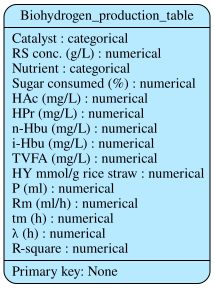

In [ ]:
metadata.visualize()

Basic Usage

Creating a Synthesizer

An SDV **synthesizer** is an object that you can use to create synthetic data. It learns patterns from the real data and replicates them to generate synthetic data.

In [ ]:
from sdv.single_table import CTGANSynthesizer

synthesizer = CTGANSynthesizer(
    metadata, # required
    enforce_min_max_values=True,
    epochs=500,
    verbose=True
)


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:138: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [ ]:

from sdv.single_table import GaussianCopulaSynthesizer
import numpy as np

# Clean the numerical columns in real_data before fitting the synthesizer
cleaned_real_data = real_data.copy()

# Identify numerical columns from the metadata
numerical_columns = []
for col_name, col_meta in metadata.tables[user_desired_table_name].columns.items():
    if col_meta['sdtype'] == 'numerical':
        numerical_columns.append(col_name)

for col in numerical_columns:
    # Convert column to string type first to handle mixed types safely
    cleaned_real_data[col] = cleaned_real_data[col].astype(str)
    # Remove spaces and commas
    cleaned_real_data[col] = cleaned_real_data[col].str.replace('\xa0', '', regex=False).str.replace(',', '', regex=False)
    # Convert to numeric, coercing errors to NaN
    cleaned_real_data[col] = pd.to_numeric(cleaned_real_data[col], errors='coerce')
    # Optionally, handle NaNs that might result from coercion if needed, e.g., fill with mean or median.
    # For this task, we will assume SDV can handle NaNs in numerical columns appropriately.
    # If not, a strategy like `cleaned_real_data[col].fillna(cleaned_real_data[col].mean(), inplace=True)` could be applied.

# Initialize the GaussianCopulaSynthesizer
gmm_synthesizer = GaussianCopulaSynthesizer(metadata)

# Fit the synthesizer to the cleaned real data
gmm_synthesizer.fit(cleaned_real_data)

<font color="maroon"><i><b>This step takes a few minutes.</b> For larger datasets, this phase may take longer. A drawback of a GAN-based model like CTGAN is performance.</i></font>

When this code finishes running, the synthesizer is ready to use.

 Generating Synthetic Data
Use the `sample` function and pass in any number of rows to synthesize.

In [ ]:
# Generate synthetic data using the GMM synthesizer
synthetic_data_from_gmm = gmm_synthesizer.sample(len(real_data) * 20)

print(f"Generated {len(synthetic_data_from_gmm)} synthetic rows using GMM.")
display(synthetic_data_from_gmm.head())

Generated 680 synthetic rows using GMM.


,Catalyst,RS conc. (g/L),Nutrient,Sugar consumed (%),HAc (mg/L),HPr (mg/L),n-Hbu (mg/L),i-Hbu (mg/L),TVFA (mg/L),HY mmol/g rice straw,P (ml),Rm (ml/h),tm (h),λ (h),R-square
0,HNO3,41,No,29.90,3656,30,1054,6.2,975.6,0.0154,23.68,1.96,11.25,0.51,0.9859
1,H2SO4,9,No,88.63,2436,333,3015,85.6,1410.1,0.0548,52.42,1.10,13.01,5.71,0.9804
2,Water,42,No,24.43,3333,378,5581,1577.2,1289.6,0.2126,91.11,6.59,11.69,3.42,0.9967
3,HCl,28,No,80.68,913,196,233,1064.1,974.4,0.0861,16.44,0.58,20.10,6.04,0.9937
4,HNO3,42,Yes,86.32,5809,163,1178,4.0,3451.8,0.2457,113.71,4.96,3.80,1.26,0.9947


In [ ]:
# Use the actual numerical columns identified from the metadata
numeric_cols = numerical_columns # This variable was correctly populated in a previous step

# Calculate group-wise min/max from cleaned_real_data
group_min_max = cleaned_real_data.groupby('Catalyst')[numeric_cols].agg(['min', 'max'])

# Define a function to enforce group-wise min/max
def enforce_group_min_max_for_row(row, group_min_max_df, group_col, numeric_columns):
    catalyst_group = row[group_col]
    if catalyst_group in group_min_max_df.index:
        for col in numeric_columns:
            # These values should now be numerical, so direct float conversion is safe
            min_val = float(group_min_max_df.loc[catalyst_group, (col, 'min')])
            max_val = float(group_min_max_df.loc[catalyst_group, (col, 'max')])
            row[col] = max(min_val, min(max_val, row[col]))
    return row

# Create a copy to store the enforced synthetic data
synthetic_data_enforced = synthetic_data_from_gmm.copy()

# Apply the enforcement function to each row of the synthetic data
synthetic_data_enforced = synthetic_data_enforced.apply(lambda row: enforce_group_min_max_for_row(row, group_min_max, 'Catalyst', numeric_cols), axis=1)

print("Synthetic data after enforcing group-wise min/max values:")
display(synthetic_data_enforced.head(680))

Synthetic data after enforcing group-wise min/max values:


,Catalyst,RS conc. (g/L),Nutrient,Sugar consumed (%),HAc (mg/L),HPr (mg/L),n-Hbu (mg/L),i-Hbu (mg/L),TVFA (mg/L),HY mmol/g rice straw,P (ml),Rm (ml/h),tm (h),λ (h),R-square
0,HNO3,41.0,No,29.90,3656.0,30.0,1054.0,6.2,1602.0,0.0324,23.68,1.96,11.25,0.51,0.9859
1,H2SO4,9.0,No,88.63,1681.0,333.0,3015.0,85.6,1410.1,0.0548,52.42,1.10,13.01,5.71,0.9804
2,Water,3.0,No,50.00,1593.0,898.0,1594.0,754.0,4155.0,0.0026,42.62,4.11,11.45,6.10,0.9967
3,HCl,28.0,No,80.68,913.0,138.0,233.0,46.0,974.4,0.0861,16.44,0.58,20.10,6.04,0.9937
4,HNO3,42.0,Yes,86.32,5809.0,163.0,1178.0,4.0,3451.8,0.2457,113.05,4.96,3.80,1.26,0.9947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
675,HCl,5.0,No,97.47,809.0,138.0,312.0,46.0,974.4,0.3044,23.23,0.40,11.60,2.61,0.9655
676,HNO3,50.0,Yes,23.00,5808.0,40.0,2347.0,4.4,14344.0,0.0324,12.21,0.81,23.17,0.46,0.9872
677,HNO3,35.0,Yes,96.00,2405.0,150.0,4973.0,180.5,1602.0,0.2906,46.30,0.52,30.53,10.39,0.9803
678,HNO3,44.0,Yes,79.82,5717.0,248.0,2444.0,185.0,4089.0,0.2906,113.05,1.45,5.58,4.80,0.9980


In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(synthetic_data_enforced)

,Catalyst,RS conc. (g/L),Nutrient,Sugar consumed (%),HAc (mg/L),HPr (mg/L),n-Hbu (mg/L),i-Hbu (mg/L),TVFA (mg/L),HY mmol/g rice straw,P (ml),Rm (ml/h),tm (h),λ (h),R-square
0,HNO3,41.0,No,29.90,3656.0,30.0,1054.0,6.2,1602.0,0.0324,23.68,1.96,11.25,0.51,0.9859
1,H2SO4,9.0,No,88.63,1681.0,333.0,3015.0,85.6,1410.1,0.0548,52.42,1.10,13.01,5.71,0.9804
2,Water,3.0,No,50.00,1593.0,898.0,1594.0,754.0,4155.0,0.0026,42.62,4.11,11.45,6.10,0.9967
3,HCl,28.0,No,80.68,913.0,138.0,233.0,46.0,974.4,0.0861,16.44,0.58,20.10,6.04,0.9937
4,HNO3,42.0,Yes,86.32,5809.0,163.0,1178.0,4.0,3451.8,0.2457,113.05,4.96,3.80,1.26,0.9947
5,HCl,9.0,Yes,19.74,809.0,129.0,64.0,46.0,974.4,0.1684,4.18,0.89,17.63,3.94,0.9740
6,HNO3,44.0,No,23.00,4315.0,184.0,5954.0,54.6,7468.3,0.1387,113.05,1.19,8.52,2.18,0.9958
7,HCl,38.0,Yes,19.26,4998.0,138.0,11857.0,46.0,2250.4,0.1416,60.43,0.39,18.65,9.86,0.9908
8,HNO3,49.0,No,23.00,1289.0,445.0,5728.0,185.0,1602.0,0.2495,12.21,0.33,30.91,7.15,0.9701
9,HCl,34.0,Yes,98.87,4253.0,138.0,187.0,46.0,14755.0,0.3008,60.43,1.32,4.29,5.42,0.9973


In [ ]:
synthesizer.fit(cleaned_real_data)
synthetic_data = synthetic_data_enforced.sample(n=680, replace=True)
synthetic_data.head()

Gen. (-01.28) | Discrim. (-00.08): 100%|██████████| 500/500 [00:44<00:00, 11.25it/s]


,Catalyst,RS conc. (g/L),Nutrient,Sugar consumed (%),HAc (mg/L),HPr (mg/L),n-Hbu (mg/L),i-Hbu (mg/L),TVFA (mg/L),HY mmol/g rice straw,P (ml),Rm (ml/h),tm (h),λ (h),R-square
592,H2SO4,18.0,No,74.48,705.0,817.0,8014.0,4396.7,1133.3,0.0244,17.52,0.54,25.67,8.88,0.9963
233,HNO3,45.0,No,67.14,4478.0,28.0,170.0,0.3,1602.0,0.2850,94.81,1.11,23.76,1.64,0.9836
439,HCl,42.0,No,19.65,2996.0,85.0,610.0,13.3,974.4,0.1414,7.17,0.37,22.96,2.18,0.9741
561,H2SO4,25.0,No,24.42,1681.0,90.0,121.0,51.0,2380.0,0.1531,30.16,0.43,13.28,0.98,0.9898
586,HNO3,37.0,Yes,96.00,3626.0,218.0,272.0,185.0,3809.4,0.1394,12.21,0.65,5.21,6.92,0.9937


 Evaluating Real vs. Synthetic Data

SDV has built-in functions for evaluating the synthetic data and getting more insight.

As a first step, we can run a **diagnostic** to ensure that the data is valid. SDV's diagnostic performs some basic checks such as:

- All primary keys must be unique
- Continuous values must adhere to the min/max of the real data
- Discrete columns (non-PII) must have the same categories as the real data
- Etc.

In [ ]:
from sdv.evaluation.single_table import run_diagnostic

diagnostic = run_diagnostic(
    real_data=cleaned_real_data,
    synthetic_data=synthetic_data_enforced,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 15/15 [00:00<00:00, 931.74it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 154.33it/s]|
Data Structure Score: 57.89%

Overall Score (Average): 78.95%



<font color="green"><b>The score is 100%</b></font>, indicating that the data is fully valid.

We can also measure the **data quality** or the statistical similarity between the real and synthetic data. This value may vary anywhere from 0 to 100%.

In [ ]:
from sdv.evaluation.single_table import evaluate_quality

quality_report = evaluate_quality(
    cleaned_real_data,
    synthetic_data_enforced,
    metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 497.04it/s]|
Column Shapes Score: 80.89%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 136.59it/s]|
Column Pair Trends Score: 73.19%

Overall Score (Average): 77.04%



The score tells us how similar the synthetic data is to the real data in terms of statistical patterns.

We can also get more details from the report. For example, the Column Shapes sub-score: Which columns had the highest vs. the lowest scores?

In [ ]:
quality_report.get_details('Column Shapes')

,Column,Metric,Score
0,Catalyst,TVComplement,0.863235
1,RS conc. (g/L),KSComplement,0.727941
2,Nutrient,TVComplement,0.935294
3,Sugar consumed (%),KSComplement,0.839706
4,HAc (mg/L),KSComplement,0.894118
5,HPr (mg/L),KSComplement,0.741176
6,n-Hbu (mg/L),KSComplement,0.795588
7,i-Hbu (mg/L),KSComplement,0.745588
8,TVFA (mg/L),KSComplement,0.539706
9,HY mmol/g rice straw,KSComplement,0.760294


 Visualizing the Data
For more insights, we can visualize the real vs. synthetic data.



### Kernel Density Estimate (KDE) Plots for Numerical Features

These plots provide a smoothed representation of the distribution of each numerical column, allowing for a direct visual comparison between the real and synthetic data.

Generating KDE plots for numerical features...


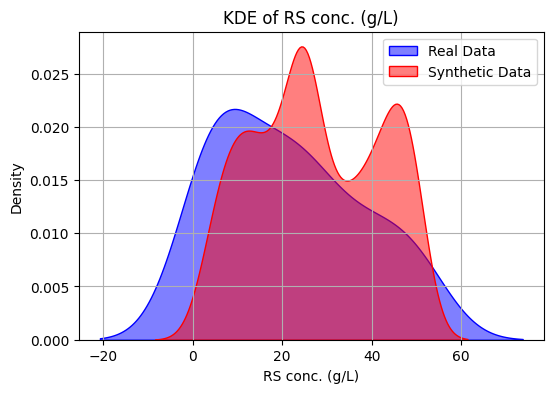

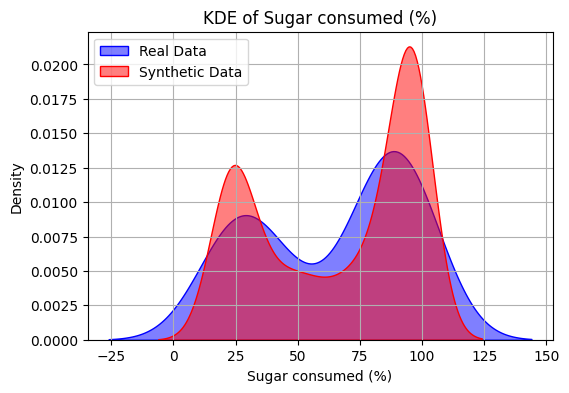

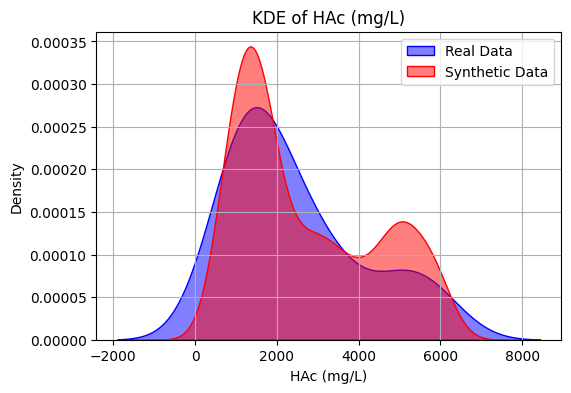

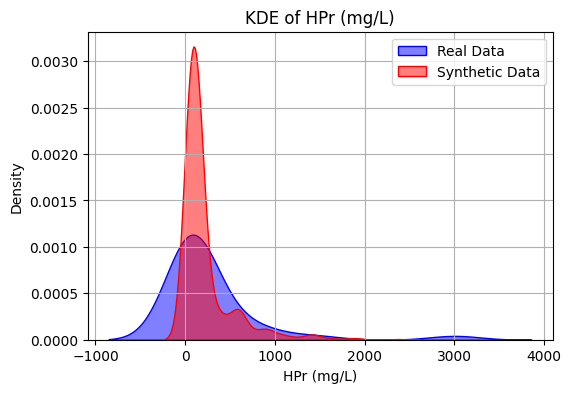

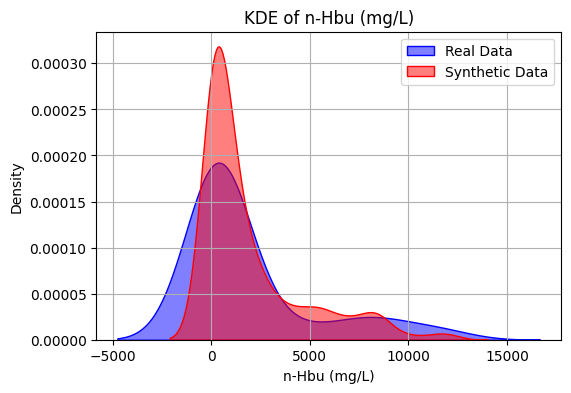

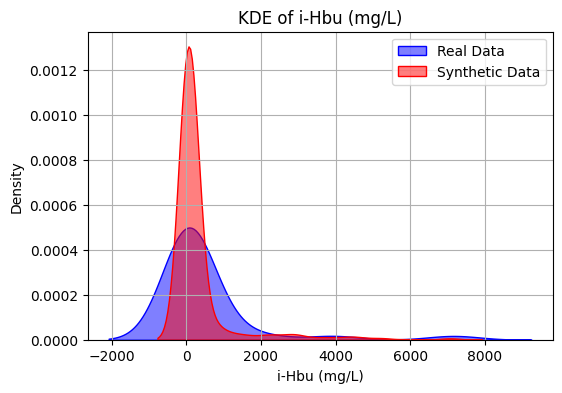

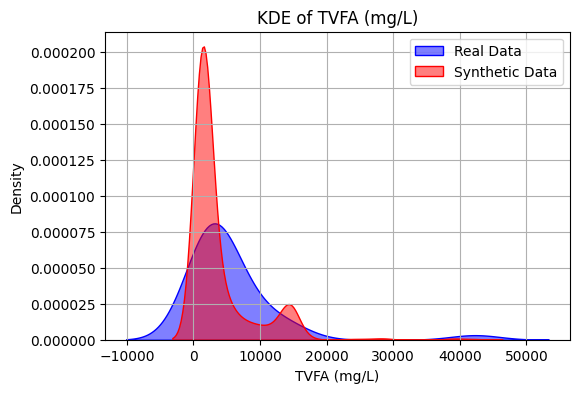

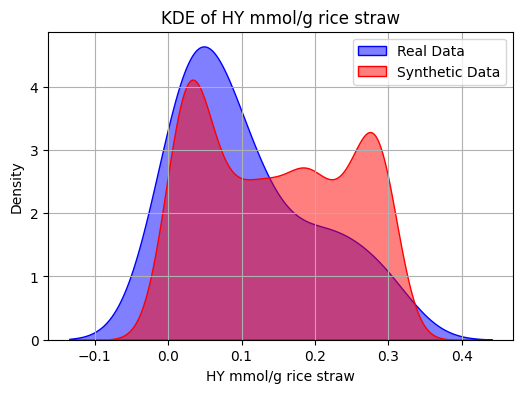

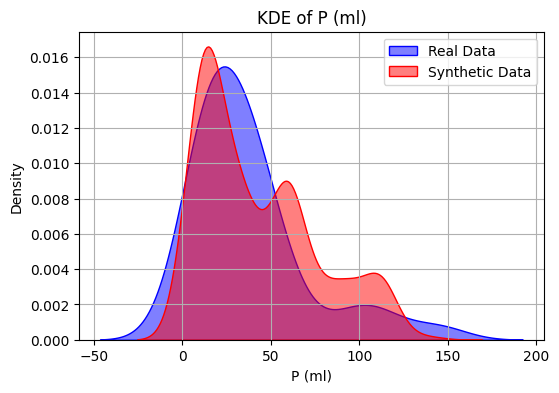

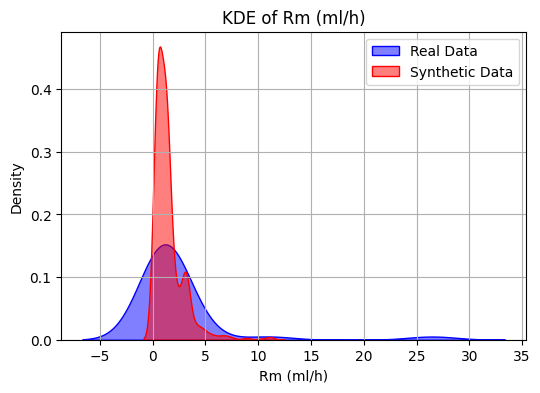

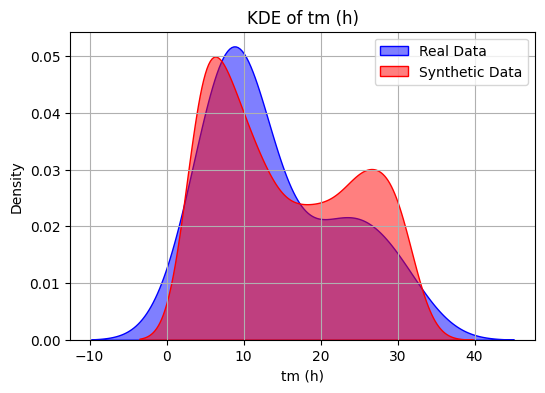

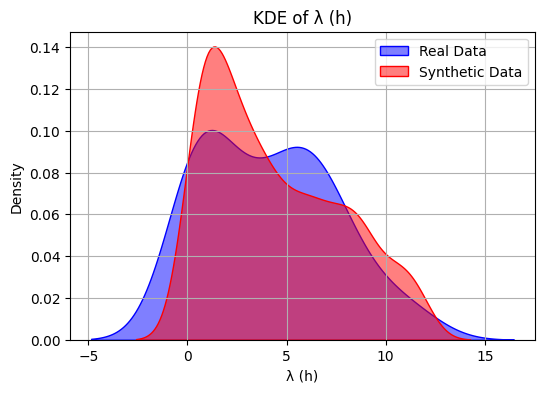

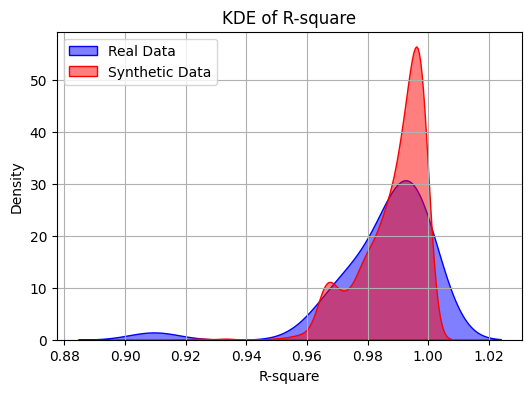

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Robustly import sdv components, installing if necessary
try:
    from sdv.metadata import Metadata
    from sdv.single_table import GaussianCopulaSynthesizer
except ImportError:
    print("sdv not found, installing...")
    !pip install sdv
    from sdv.metadata import Metadata
    from sdv.single_table import GaussianCopulaSynthesizer

# Ensure real_data is loaded
if 'real_data' not in locals() and 'real_data' not in globals():
    print("Loading real_data...")
    real_data = pd.read_csv('Biohydrogen_production (1).csv') # Changed filename back to original

# Ensure categorical_features is defined
if 'categorical_features' not in locals() and 'categorical_features' not in globals():
    categorical_features = ['Catalyst', 'Nutrient']

user_desired_table_name = 'Biohydrogen_production_table'

# Ensure metadata and numerical_columns are defined
if 'metadata' not in locals() or 'numerical_columns' not in globals():
    print("Detecting metadata and numerical columns...")
    metadata = Metadata.detect_from_dataframe(data=real_data, table_name=user_desired_table_name)
    for col in real_data.columns:
        if col in categorical_features:
            metadata.tables[user_desired_table_name].columns[col]['sdtype'] = 'categorical'
        else:
            metadata.tables[user_desired_table_name].columns[col]['sdtype'] = 'numerical'
    metadata.tables[user_desired_table_name].primary_key = None

    numerical_columns = []
    for col_name, col_meta in metadata.tables[user_desired_table_name].columns.items():
        if col_meta['sdtype'] == 'numerical':
            numerical_columns.append(col_name)

# Ensure cleaned_real_data is available
if 'cleaned_real_data' not in locals() and 'cleaned_real_data' not in globals():
    print("Creating cleaned_real_data...")
    cleaned_real_data = real_data.copy()
    for col in numerical_columns:
        cleaned_real_data[col] = cleaned_real_data[col].astype(str)
        cleaned_real_data[col] = cleaned_real_data[col].str.replace('\xa0', '', regex=False).str.replace(',', '', regex=False)
        cleaned_real_data[col] = pd.to_numeric(cleaned_real_data[col], errors='coerce')

# Ensure synthetic_data_enforced is available
if 'synthetic_data_enforced' not in locals() and 'synthetic_data_enforced' not in globals():
    print("Generating synthetic_data_enforced...")
    # Initialize and fit synthesizer
    gmm_synthesizer = GaussianCopulaSynthesizer(metadata)
    gmm_synthesizer.fit(cleaned_real_data)
    synthetic_data_from_gmm = gmm_synthesizer.sample(len(real_data) * 20)

    # Replicate enforcement logic (assuming Catalyst is the grouping column)
    numeric_cols = numerical_columns
    group_min_max = cleaned_real_data.groupby('Catalyst')[numeric_cols].agg(['min', 'max'])
    def enforce_group_min_max_for_row(row, group_min_max_df, group_col, numeric_columns):
        catalyst_group = row[group_col]
        if catalyst_group in group_min_max_df.index:
            for col in numeric_columns:
                min_val = float(group_min_max_df.loc[catalyst_group, (col, 'min')])
                max_val = float(group_min_max_df.loc[catalyst_group, (col, 'max')])
                row[col] = max(min_val, min(max_val, row[col]))
        return row
    synthetic_data_enforced = synthetic_data_from_gmm.copy()
    synthetic_data_enforced = synthetic_data_enforced.apply(lambda row: enforce_group_min_max_for_row(row, group_min_max, 'Catalyst', numeric_cols), axis=1)


print("Generating KDE plots for numerical features...")

for col_name in numerical_columns:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(cleaned_real_data[col_name].dropna(), label='Real Data', color='blue', fill=True, alpha=0.5)
    sns.kdeplot(synthetic_data_enforced[col_name].dropna(), label='Synthetic Data', color='red', fill=True, alpha=0.5)
    plt.title(f'KDE of {col_name}')
    plt.xlabel(col_name)
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
!pip install shap

In [ ]:
!pip install numpy

Generating association heatmap for cleaned_real_data...


/usr/local/lib/python3.12/dist-packages/dython/nominal.py:161: RuntimeWarning: Unable to calculate Cramer's V using bias correction. Consider using bias_correction=False (or cramers_v_bias_correction=False if calling from associations)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/dython/nominal.py:161: RuntimeWarning: Unable to calculate Cramer's V using bias correction. Consider using bias_correction=False (or cramers_v_bias_correction=False if calling from associations)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/dython/nominal.py:161: RuntimeWarning: Unable to calculate Cramer's V using bias correction. Consider using bias_correction=False (or cramers_v_bias_correction=False if calling from associations)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/dython/nominal.py:161: RuntimeWarning: Unable to calculate Cramer's V using bias correction. Consider using bias_correction=False (or cramers_v_bias_correction=False if calling from associations)
  war

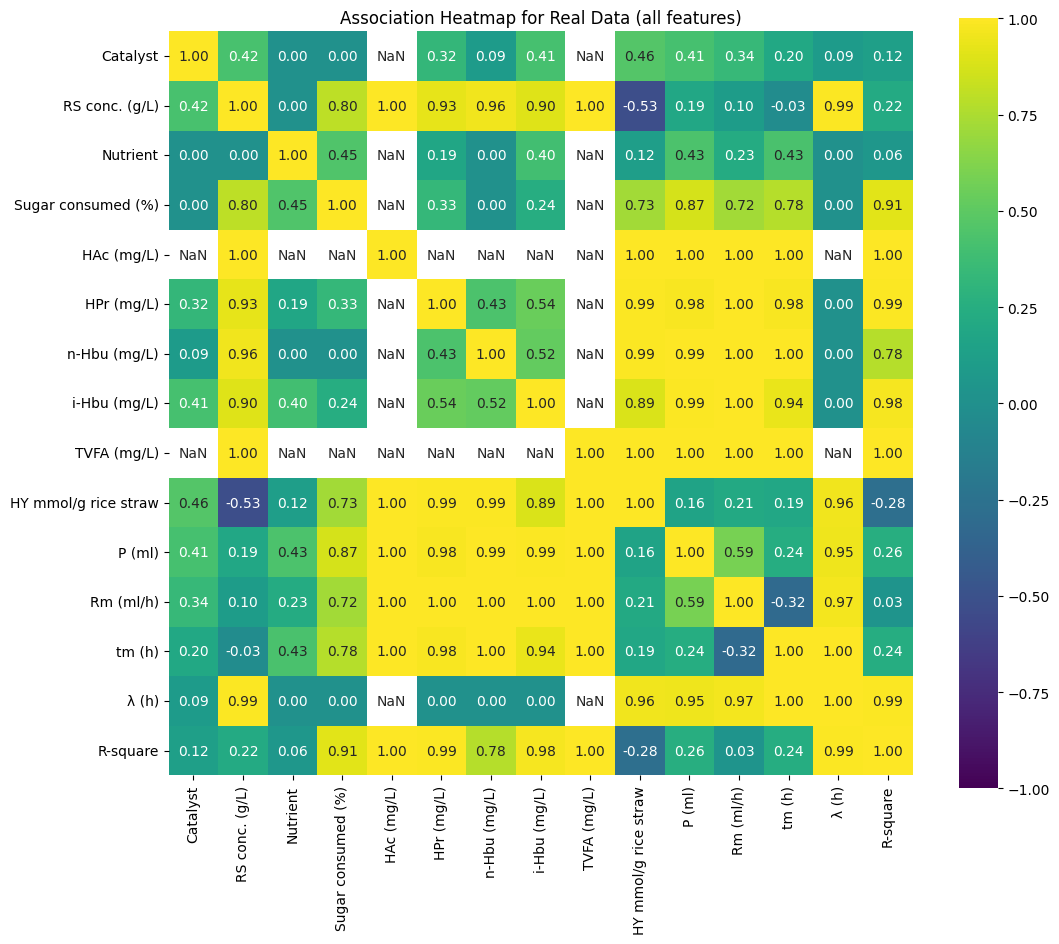

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from dython.nominal import associations
import pandas as pd

# Get all columns except 'samples' since it's also categorical but not the focus here
# The 'associations' function will handle all types correctly.

# Ensure real_data is defined if this cell is run out of order or after a kernel restart
# Assuming 'Biohydrogen_production.csv' is available in the current directory
real_data = pd.read_csv('Biohydrogen_production.csv')

print("Generating association heatmap for cleaned_real_data...")
plt.figure(figsize=(12, 10))
associations(
    real_data,
    ax=plt.gca(),
    cmap='viridis',
    cbar=True,
    annot=True,
    fmt='.2f',
    title='Association Heatmap for Real Data (all features)'
)
plt.show()

Generating association heatmap for synthetic_data_enforced...


/usr/local/lib/python3.12/dist-packages/dython/nominal.py:161: RuntimeWarning: Unable to calculate Cramer's V using bias correction. Consider using bias_correction=False (or cramers_v_bias_correction=False if calling from associations)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/dython/nominal.py:161: RuntimeWarning: Unable to calculate Cramer's V using bias correction. Consider using bias_correction=False (or cramers_v_bias_correction=False if calling from associations)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/dython/nominal.py:161: RuntimeWarning: Unable to calculate Cramer's V using bias correction. Consider using bias_correction=False (or cramers_v_bias_correction=False if calling from associations)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/dython/nominal.py:161: RuntimeWarning: Unable to calculate Cramer's V using bias correction. Consider using bias_correction=False (or cramers_v_bias_correction=False if calling from associations)
  war

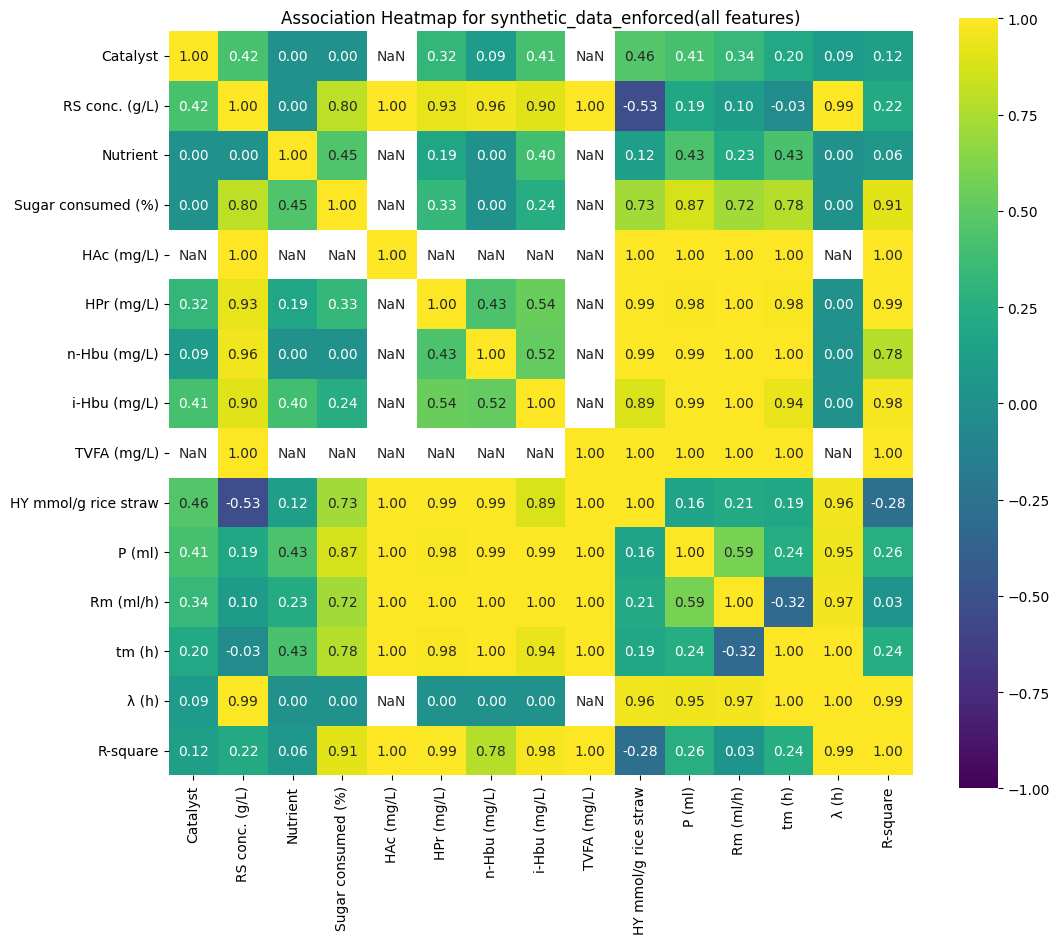

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from dython.nominal import associations
import pandas as pd

# Get all columns except 'samples' since it's also categorical but not the focus here
# The 'associations' function will handle all types correctly.

# Ensure real_data is defined if this cell is run out of order or after a kernel restart
# Assuming 'Biohydrogen_production.csv' is available in the current directory
real_data = pd.read_csv('Biohydrogen_production.csv')

print("Generating association heatmap for synthetic_data_enforced...")
plt.figure(figsize=(12, 10))
associations(
    real_data,
    ax=plt.gca(),
    cmap='viridis',
    cbar=True,
    annot=True,
    fmt='.2f',
    title='Association Heatmap for synthetic_data_enforced(all features)'
)
plt.show()

### Impact of 'RS conc.' on 'HY' and 'TVFA'

To study the impact of 'RS conc. (g/L)' on 'HY mmol/g rice straw' and 'TVFA (mg/L)', we can visualize their relationships using scatter plots.

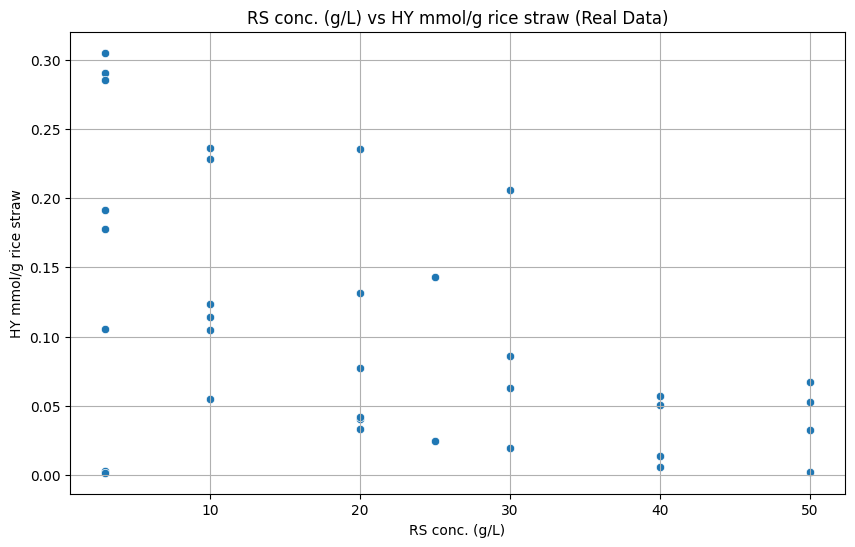

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot for RS conc. vs HY mmol/g rice straw
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cleaned_real_data, x='RS conc. (g/L)', y='HY mmol/g rice straw')
plt.title('RS conc. (g/L) vs HY mmol/g rice straw (Real Data)')
plt.xlabel('RS conc. (g/L)')
plt.ylabel('HY mmol/g rice straw')
plt.grid(True)
plt.show()

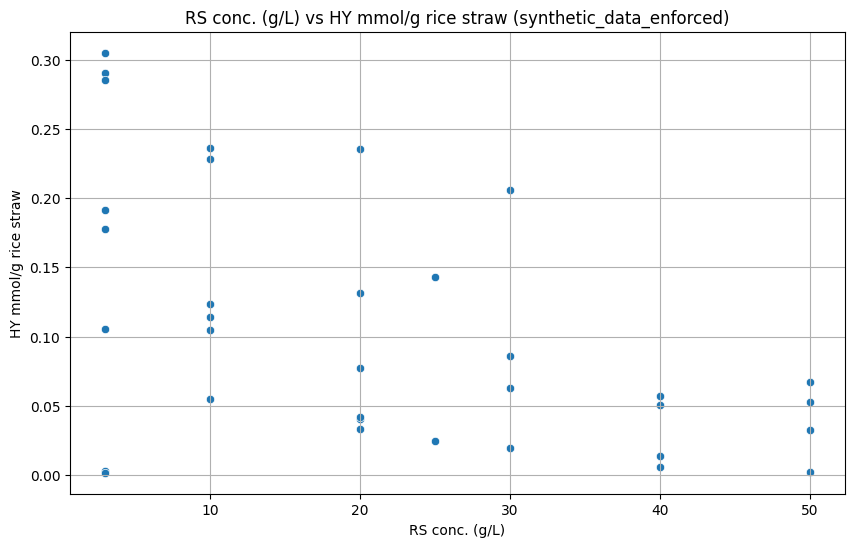

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot for RS conc. vs HY mmol/g rice straw
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cleaned_real_data, x='RS conc. (g/L)', y='HY mmol/g rice straw')
plt.title('RS conc. (g/L) vs HY mmol/g rice straw (synthetic_data_enforced)')
plt.xlabel('RS conc. (g/L)')
plt.ylabel('HY mmol/g rice straw')
plt.grid(True)
plt.show()

### Kolmogorov-Smirnov (KS) Test for Distribution Comparison

To quantitatively compare the distributions of numerical features between the `cleaned_real_data` and `synthetic_data_enforced`, we can use the Kolmogorov-Smirnov (KS) test. This test checks if two samples are drawn from the same continuous distribution. A small p-value (typically < 0.05) suggests that the distributions are significantly different.

In [ ]:
from scipy.stats import ks_2samp

print("\n--- Kolmogorov-Smirnov (KS) Test Results ---")
print("Comparing distributions of numerical columns between cleaned_real_data and Synthetic_enfore_Data")

ks_results = []
for col in numerical_columns:
    # Drop NaNs to ensure the KS test can run without issues
    real_series = cleaned_real_data[col].dropna()
    synthetic_series = synthetic_data_enforced[col].dropna()

    # Ensure there are enough data points for the test
    if len(real_series) > 1 and len(synthetic_series) > 1:
        statistic, p_value = ks_2samp(real_series, synthetic_series)
        ks_results.append({'Column': col, 'KS_Statistic': statistic, 'P_Value': p_value})
    else:
        ks_results.append({'Column': col, 'KS_Statistic': 'N/A', 'P_Value': 'Not enough data'})

ks_df = pd.DataFrame(ks_results)
print(ks_df.to_string())

print("\nInterpretation: A lower KS Statistic and a higher P-Value (e.g., > 0.05) indicate that the two distributions (real and synthetic) are more similar and likely come from the same underlying distribution.")


--- Kolmogorov-Smirnov (KS) Test Results ---
Comparing distributions of numerical columns between cleaned_real_data and Synthetic_enfore_Data
                  Column  KS_Statistic       P_Value
0         RS conc. (g/L)      0.272059  1.342645e-02
1     Sugar consumed (%)      0.160294  3.430531e-01
2             HAc (mg/L)      0.105882  8.279779e-01
3             HPr (mg/L)      0.258824  2.157758e-02
4           n-Hbu (mg/L)      0.204412  1.173651e-01
5           i-Hbu (mg/L)      0.254412  2.513614e-02
6            TVFA (mg/L)      0.460294  9.124122e-07
7   HY mmol/g rice straw      0.239706  4.099581e-02
8                 P (ml)      0.214706  8.790073e-02
9              Rm (ml/h)      0.111765  7.767463e-01
10                tm (h)      0.144118  4.731036e-01
11                 λ (h)      0.133456  6.004031e-01
12              R-square      0.104412  8.400679e-01

Interpretation: A lower KS Statistic and a higher P-Value (e.g., > 0.05) indicate that the two distributions (real

In [ ]:
print("\n--- Kolmogorov-Smirnov (KS) Test Results Table (Normal P-Value Format) ---")
# Set pandas display option to show floats with a fixed number of decimal places
# This will prevent scientific notation for p-values.
pd.set_option('display.float_format', lambda x: '%.10f' % x)
display(ks_df)
# Reset the display option to default if desired for subsequent outputs
pd.reset_option('display.float_format')


--- Kolmogorov-Smirnov (KS) Test Results Table (Normal P-Value Format) ---


,Column,KS_Statistic,P_Value
0,RS conc. (g/L),0.2720588235,0.0134264545
1,Sugar consumed (%),0.1602941176,0.3430530571
2,HAc (mg/L),0.1058823529,0.8279779052
3,HPr (mg/L),0.2588235294,0.0215775774
4,n-Hbu (mg/L),0.2044117647,0.1173650760
5,i-Hbu (mg/L),0.2544117647,0.0251361449
6,TVFA (mg/L),0.4602941176,0.0000009124
7,HY mmol/g rice straw,0.2397058824,0.0409958120
8,P (ml),0.2147058824,0.0879007296
9,Rm (ml/h),0.1117647059,0.7767462930


### Ranking Catalysts by 'RS conc. (g/L)' and 'HY mmol/g rice straw' Production

In [ ]:
# Ranking for cleaned_real_data
print("\n--- Ranking Catalysts in Cleaned Real Data ---")
real_catalyst_ranking = cleaned_real_data.groupby('Catalyst')[['RS conc. (g/L)', 'HY mmol/g rice straw']].mean().sort_values(by=['RS conc. (g/L)', 'HY mmol/g rice straw'], ascending=[False, False])
display(real_catalyst_ranking)

# Ranking for synthetic_data_enforced
print("\n--- Ranking Catalysts in Synthetic Enforced Data ---")
synthetic_catalyst_ranking = synthetic_data_enforced.groupby('Catalyst')[['RS conc. (g/L)', 'HY mmol/g rice straw']].mean().sort_values(by=['RS conc. (g/L)', 'HY mmol/g rice straw'], ascending=[False, False])
display(synthetic_catalyst_ranking)


--- Ranking Catalysts in Cleaned Real Data ---


,RS conc. (g/L),HY mmol/g rice straw
Catalyst,,
HNO3,25.5,0.153050
HCl,25.5,0.075433
H2SO4,14.5,0.107137
Water,3.0,0.002100



--- Ranking Catalysts in Synthetic Enforced Data ---


,RS conc. (g/L),HY mmol/g rice straw
Catalyst,,
HNO3,30.636637,0.183685
HCl,28.351351,0.124714
H2SO4,19.486726,0.089481
Water,3.000000,0.002550


### Heatmap Visualization of Catalyst Rankings

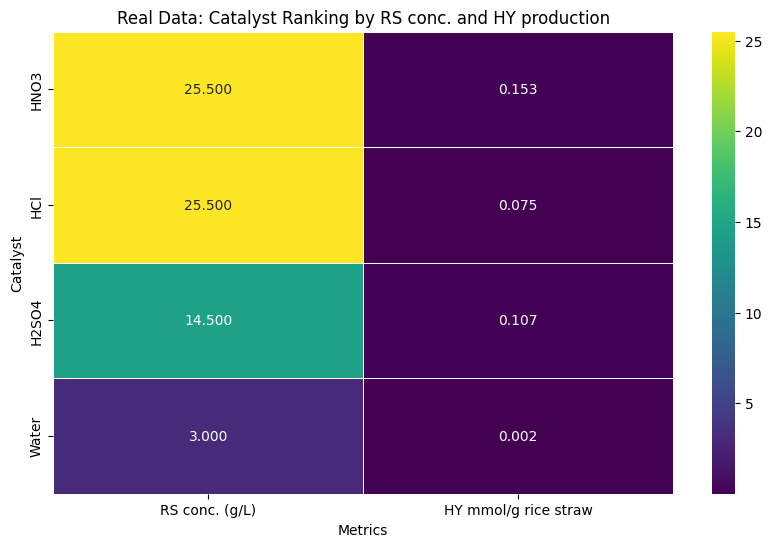

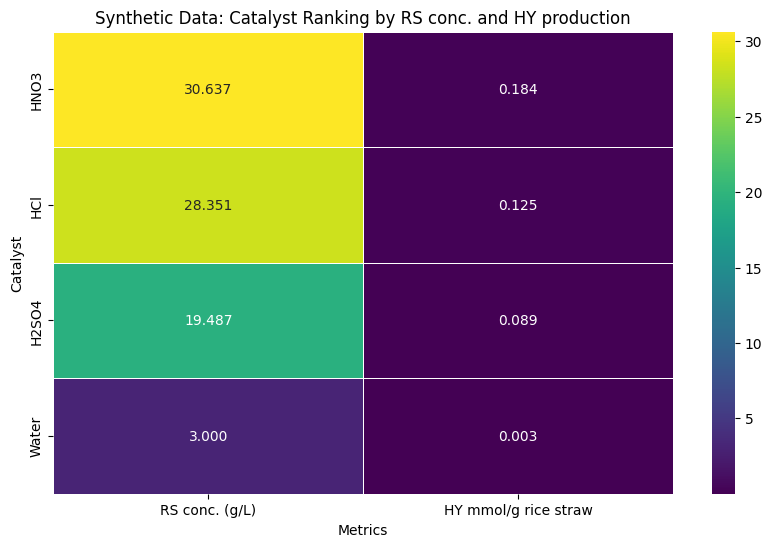

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap for Real Data Catalyst Ranking
plt.figure(figsize=(10, 6))
sns.heatmap(real_catalyst_ranking, annot=True, cmap='viridis', fmt=".3f", linewidths=.5)
plt.title('Real Data: Catalyst Ranking by RS conc. and HY production')
plt.xlabel('Metrics')
plt.ylabel('Catalyst')
plt.show()

# Heatmap for Synthetic Enforced Data Catalyst Ranking
plt.figure(figsize=(10, 6))
sns.heatmap(synthetic_catalyst_ranking, annot=True, cmap='viridis', fmt=".3f", linewidths=.5)
plt.title('Synthetic Data: Catalyst Ranking by RS conc. and HY production')
plt.xlabel('Metrics')
plt.ylabel('Catalyst')
plt.show()

### Skewness and Kurtosis for Real and Synthetic Data

Skewness measures the asymmetry of the probability distribution of a real-valued random variable about its mean. Kurtosis measures the 'tailedness' of the probability distribution of a real-valued random variable.

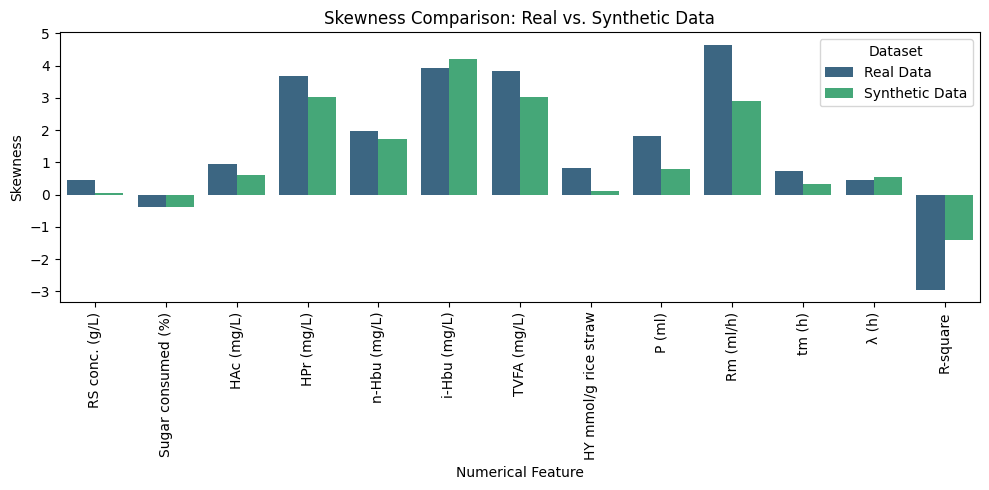

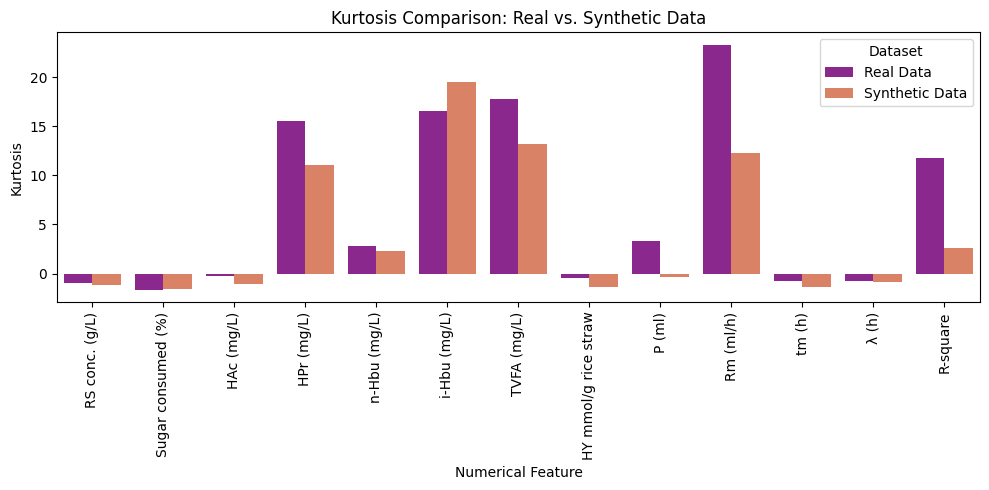

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate skewness for both datasets
real_skewness = cleaned_real_data.skew(numeric_only=True).rename('Real Data Skewness')
synthetic_skewness = synthetic_data_enforced.skew(numeric_only=True).rename('Synthetic Data Skewness')

# Calculate kurtosis for both datasets
real_kurtosis = cleaned_real_data.kurt(numeric_only=True).rename('Real Data Kurtosis')
synthetic_kurtosis = synthetic_data_enforced.kurt(numeric_only=True).rename('Synthetic Data Kurtosis')

# Combine skewness results into a DataFrame
skewness_df = pd.DataFrame({
    'Real Data': real_skewness,
    'Synthetic Data': synthetic_skewness
}).reset_index()
skewness_df = skewness_df.rename(columns={'index': 'Feature'})
skewness_df_melted = skewness_df.melt(id_vars='Feature', var_name='Dataset', value_name='Skewness Value')

# Combine kurtosis results into a DataFrame
kurtosis_df = pd.DataFrame({
    'Real Data': real_kurtosis,
    'Synthetic Data': synthetic_kurtosis
}).reset_index()
kurtosis_df = kurtosis_df.rename(columns={'index': 'Feature'})
kurtosis_df_melted = kurtosis_df.melt(id_vars='Feature', var_name='Dataset', value_name='Kurtosis Value')


# Plotting Skewness
plt.figure(figsize=(10, 5))
sns.barplot(x='Feature', y='Skewness Value', hue='Dataset', data=skewness_df_melted, palette='viridis')
plt.title('Skewness Comparison: Real vs. Synthetic Data')
plt.xlabel('Numerical Feature')
plt.ylabel('Skewness')
plt.xticks(rotation=90)
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

# Plotting Kurtosis
plt.figure(figsize=(10, 5))
sns.barplot(x='Feature', y='Kurtosis Value', hue='Dataset', data=kurtosis_df_melted, palette='plasma')
plt.title('Kurtosis Comparison: Real vs. Synthetic Data')
plt.xlabel('Numerical Feature')
plt.ylabel('Kurtosis')
plt.xticks(rotation=90)
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

### Prediction GUI for 'HY mmol/g rice straw'

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Ensure X_real and y_real are derived from cleaned_real_data
target_column = 'HY mmol/g rice straw'
features = [col for col in numerical_columns if col != target_column]

# Drop rows with NaN values in target or features
real_data_processed = cleaned_real_data[features + [target_column]].dropna()
X_real = real_data_processed[features]
y_real = real_data_processed[target_column]

# Train a RandomForestRegressor model on the entire cleaned real data
# Using a consistent random_state for reproducibility
model = RandomForestRegressor(random_state=42, n_estimators=50)
model.fit(X_real, y_real)

print("RandomForestRegressor model trained successfully for HY prediction.")

def predict_hy(input_features):
    """
    Predicts 'HY mmol/g rice straw' using the trained RandomForestRegressor model.
    input_features should be a pandas Series or dictionary with feature names matching X_real.
    """
    input_df = pd.DataFrame([input_features])
    prediction = model.predict(input_df)
    return prediction[0]


RandomForestRegressor model trained successfully for HY prediction.


In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML

# Create input widgets for each feature
input_widgets = {}
for feature in features:
    input_widgets[feature] = widgets.FloatText(
        value=X_real[feature].mean(),  # Initialize with mean of real data
        description=feature,
        disabled=False
    )

# Create a button for prediction
predict_button = widgets.Button(description="Predict HY")

# Create an output widget to display the prediction
output_label = widgets.Output()

def on_predict_button_clicked(b):
    with output_label:
        output_label.clear_output()
        input_values = {feature: widget.value for feature, widget in input_widgets.items()}
        try:
            prediction = predict_hy(input_values)
            print(f"Predicted HY mmol/g rice straw: {prediction:.4f}")
        except Exception as e:
            print(f"Error during prediction: {e}")

predict_button.on_click(on_predict_button_clicked)

# Arrange widgets
input_widget_box = widgets.VBox(list(input_widgets.values()))
display(widgets.VBox([input_widget_box, predict_button, output_label]))


In [ ]:
import pandas as pd

# Calculate Skewness for cleaned_real_data
print('Skewness for cleaned Real Data:')
display(cleaned_real_data.skew(numeric_only=True))

# Calculate Kurtosis for cleaned_real_data
print('\nKurtosis for cleaned Real Data:')
display(cleaned_real_data.kurt(numeric_only=True))

Skewness for cleaned Real Data:


RS conc. (g/L)          0.456947
Sugar consumed (%)     -0.382584
HAc (mg/L)              0.947895
HPr (mg/L)              3.686835
n-Hbu (mg/L)            1.979180
i-Hbu (mg/L)            3.930270
TVFA (mg/L)             3.844616
HY mmol/g rice straw    0.819866
P (ml)                  1.825938
Rm (ml/h)               4.653323
tm (h)                  0.743794
λ (h)                   0.438629
R-square               -2.948293
dtype: float64


Kurtosis for cleaned Real Data:


RS conc. (g/L)          -1.006875
Sugar consumed (%)      -1.635022
HAc (mg/L)              -0.245662
HPr (mg/L)              15.550624
n-Hbu (mg/L)             2.782759
i-Hbu (mg/L)            16.513413
TVFA (mg/L)             17.821066
HY mmol/g rice straw    -0.500521
P (ml)                   3.287252
Rm (ml/h)               23.314713
tm (h)                  -0.711910
λ (h)                   -0.730491
R-square                11.783658
dtype: float64

In [ ]:
# Calculate Skewness for synthetic_data_enforced
print('Skewness for Synthetic Enforced Data:')
display(synthetic_data_enforced.skew(numeric_only=True))

# Calculate Kurtosis for synthetic_data_enforced
print('\nKurtosis for Synthetic Enforced Data:')
display(synthetic_data_enforced.kurt(numeric_only=True))

Skewness for Synthetic Enforced Data:


RS conc. (g/L)          0.049075
Sugar consumed (%)     -0.391660
HAc (mg/L)              0.600159
HPr (mg/L)              3.021099
n-Hbu (mg/L)            1.735279
i-Hbu (mg/L)            4.208827
TVFA (mg/L)             3.042295
HY mmol/g rice straw    0.103692
P (ml)                  0.796504
Rm (ml/h)               2.918321
tm (h)                  0.316794
λ (h)                   0.558420
R-square               -1.399752
dtype: float64


Kurtosis for Synthetic Enforced Data:


RS conc. (g/L)          -1.187239
Sugar consumed (%)      -1.573248
HAc (mg/L)              -1.075262
HPr (mg/L)              11.050707
n-Hbu (mg/L)             2.278634
i-Hbu (mg/L)            19.465494
TVFA (mg/L)             13.156349
HY mmol/g rice straw    -1.413803
P (ml)                  -0.392806
Rm (ml/h)               12.276073
tm (h)                  -1.321490
λ (h)                   -0.853504
R-square                 2.593561
dtype: float64

## 2.6 Saving and Loading
We can save the synthesizer to share with others and sample more synthetic data in the future.

In [ ]:
gmm_synthesizer.save('synthetic_data_enforced.pkl')

In [ ]:
from sdv.utils import load_synthesizer
synthesizer = load_synthesizer('synthetic_data_enforced.pkl')

